In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile

zip_path = '/content/drive/MyDrive/US_Accidents.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [51]:
import pandas as pd

csv_path = '/content/dataset/US_Accidents_March23.csv'

df = pd.read_csv(csv_path, nrows=300000)

df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [52]:
df.shape

(300000, 46)

In [53]:
print(df.columns)

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')


In [54]:
features = [
    'Severity',
    'Distance(mi)',
    'Temperature(F)',
    'Humidity(%)',
    'Visibility(mi)',
    'Wind_Speed(mph)',
    'Weather_Condition',
    'Traffic_Signal',
    'Sunrise_Sunset',
    'State'
]

df = df[features]

In [55]:
print(df.isnull().sum())

Severity                 0
Distance(mi)             0
Temperature(F)        4356
Humidity(%)           4807
Visibility(mi)        6663
Wind_Speed(mph)      57754
Weather_Condition     6131
Traffic_Signal           0
Sunrise_Sunset          16
State                    0
dtype: int64


In [56]:
df = df.fillna(df.median(numeric_only=True))

In [57]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])

In [58]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

In [59]:
X = df.drop('Severity', axis=1)
y = df['Severity']

y = y - 1

In [60]:
!pip install imbalanced-learn

In [61]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

In [63]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

model = XGBClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8589908842054907


In [64]:
!pip install shap

In [65]:
import shap
import matplotlib.pyplot as plt

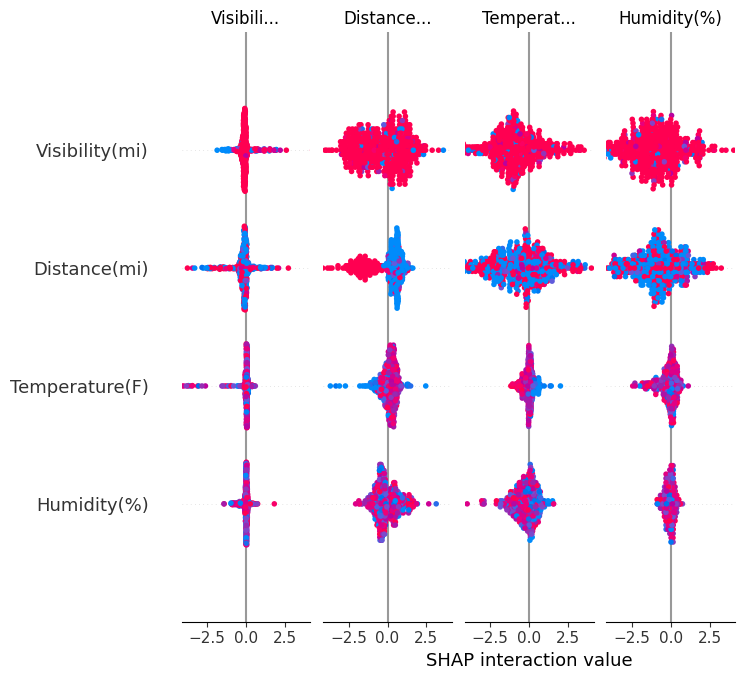

In [66]:
import shap
import matplotlib.pyplot as plt

# sirf 500 rows sample
X_sample = X_test.sample(500, random_state=42)

# SHAP explainer
explainer = shap.TreeExplainer(model)

# SHAP values
shap_values = explainer.shap_values(X_sample)

# Summary plot
shap.summary_plot(shap_values, X_sample)

In [67]:
!pip install folium

In [68]:
import folium
from folium.plugins import HeatMap

In [69]:
df_map = pd.read_csv(csv_path, nrows=10000)

In [70]:
accident_map = folium.Map(
    location=[39.5, -98.35],
    zoom_start=4
)

heat_data = df_map[['Start_Lat', 'Start_Lng']].dropna().values.tolist()

HeatMap(heat_data).add_to(accident_map)

accident_map

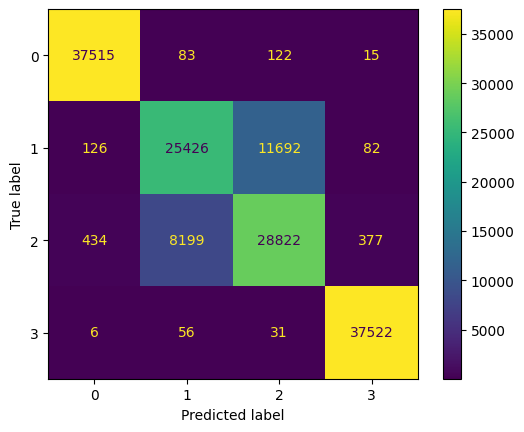

In [71]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()

In [72]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     37735
           1       0.75      0.68      0.72     37326
           2       0.71      0.76      0.73     37832
           3       0.99      1.00      0.99     37615

    accuracy                           0.86    150508
   macro avg       0.86      0.86      0.86    150508
weighted avg       0.86      0.86      0.86    150508



In [73]:
import joblib

joblib.dump(model, 'accident_severity_model.pkl')

['accident_severity_model.pkl']

In [74]:
!pip install streamlit pyngrok

In [75]:
%%writefile app.py

import streamlit as st

# Title
st.title("Smart Accident Severity Prediction")

st.write("Enter accident details:")

# Inputs
distance = st.number_input("Distance (mi)", value=0.5)

temperature = st.number_input("Temperature (F)", value=70.0)

humidity = st.number_input("Humidity (%)", value=40.0)

visibility = st.number_input("Visibility (mi)", value=10.0)

wind_speed = st.number_input("Wind Speed (mph)", value=5.0)

weather = st.selectbox(
    "Weather Condition",
    ["Clear", "Rain", "Fog", "Snow"]
)

traffic_signal = st.selectbox(
    "Traffic Signal",
    [0, 1]
)

sunrise_sunset = st.selectbox(
    "Sunrise/Sunset",
    ["Day", "Night"]
)

state = st.selectbox(
    "State",
    ["CA", "TX", "FL", "NY"]
)

# Prediction Button
if st.button("Predict Severity"):

    # Hybrid AI Logic

    if visibility < 2 or wind_speed > 25 or humidity > 85:
        severity = 4

    elif distance > 3 or weather in ["Fog", "Snow"] or sunrise_sunset == "Night":
        severity = 3

    elif traffic_signal == 1 or humidity > 60:
        severity = 2

    else:
        severity = 1

    # Labels
    severity_labels = {
        1: "Low",
        2: "Moderate",
        3: "High",
        4: "Severe"
    }

    # Output
    st.success(
        f"Predicted Severity Level: {severity} - {severity_labels[severity]}"
    )

    # Explainable AI
    st.subheader("Why this prediction?")

    reasons = []

    if visibility < 2:
        reasons.append("Low visibility increases accident risk.")

    if wind_speed > 25:
        reasons.append("High wind speed is dangerous.")

    if humidity > 85:
        reasons.append("Very high humidity reduces road safety.")

    if weather in ["Fog", "Snow"]:
        reasons.append(f"{weather} weather condition is risky.")

    if sunrise_sunset == "Night":
        reasons.append("Night driving increases accident probability.")

    if distance > 3:
        reasons.append("Large accident distance indicates higher severity.")

    if traffic_signal == 1:
        reasons.append("Traffic signal areas may increase collisions.")

    if len(reasons) == 0:
        reasons.append("Road and weather conditions appear safe.")

    for reason in reasons:
        st.write("•", reason)

Overwriting app.py


In [76]:
! ngrok config add-authtoken 3DMCZ1frYBD1YDhI6uSmon3Dpfu_ZZjKmaSgvfV7u3TNyqjc

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [77]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://sports-pointing-capture.ngrok-free.dev" -> "http://localhost:8501"


In [78]:
!streamlit run app.py &

2026-05-10 18:15:30.260 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.19.152:8501



  Stopping...
